# Q-Peptide — quantum-assisted antimicrobial peptide design

**A constrained quadratic binary optimization problem, solved with QAOA and verified
against brute force.**

Given a known antimicrobial peptide, which two or three amino-acid substitutions most
improve the predicted activity-versus-hemolysis trade-off?

With ~14 candidate substitutions there are thousands of combinations, the substitutions
**interact**, and some are **mutually exclusive** (two residues cannot occupy one
position). That is a QUBO:

$$\max_{x}\;\; \widehat{\Delta S}(x) = \sum_i \Delta_i x_i + \sum_{i<j} \Delta_{ij} x_i x_j
\quad\text{s.t.}\quad \sum_i x_i \le K,\;\; x_i + x_j \le 1,\;\; x_i \in \{0,1\}$$

> The quantum computer is **not** simulating protein folding. It solves the
> subset-selection problem above.

> ⚠️ **Every biological value in this notebook is a model prediction.** Nothing has been
> synthesised or assayed.

---

### What makes this formulation different

The coefficients $\Delta_i$ and $\Delta_{ij}$ are **computed by running the ML models on
the actual mutant sequences** — not fitted to sampled scores. That removes a layer of
surrogate error and, critically, makes the error that remains *measurable*.

In [1]:
import sys, os, json, time
sys.path.insert(0, os.path.abspath(".."))
os.chdir(os.path.abspath(".."))   # run from the repository root

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})

from backend.models.property_models import BiologicalScorer, ScoreWeights

SEED = 20261004
PARENT = "GIGKFLHSAKKFGKAFVGEIMNS"   # Magainin 2
print("parent:", PARENT, f"({len(PARENT)} residues)")

parent: GIGKFLHSAKKFGKAFVGEIMNS (23 residues)


## 1. The parent peptide and the two property models

Two independently trained XGBoost regressors, both on the pharmacological log-dose scale
`6 − log₁₀(c[µM])`:

- **activity** — higher is better (more potent)
- **hemolysis** — higher is **worse** (lyses red blood cells at a lower dose)

Combined into one score, with the sign convention fixed in exactly one place:

$$S(P) = \alpha\,\tilde A(P) - \beta\,\tilde H(P) \qquad \textbf{larger is better}$$

In [2]:
scorer = BiologicalScorer.load(weights=ScoreWeights(alpha=1.0, beta=1.0))
b = scorer.breakdown([PARENT])

print(f"predicted activity   {b.activity_raw[0]:7.3f}   (pMIC scale, higher = more active)")
print(f"predicted hemolysis  {b.hemolysis_raw[0]:7.3f}   (p-dose scale, higher = MORE hemolytic)")
print(f"score S(P)           {b.score[0]:7.4f}")
print()
print("activity model :", scorer.activity.metadata["target_definition"])
print("  held-out MAE :", round(scorer.activity.metadata["heldout_test_mae"], 4),
      " Spearman:", round(scorer.activity.metadata["heldout_test_spearman"], 4))
print("hemolysis model:", scorer.hemolysis.metadata["target_definition"])
print("  held-out MAE :", round(scorer.hemolysis.metadata["heldout_test_mae"], 4),
      " Spearman:", round(scorer.hemolysis.metadata["heldout_test_spearman"], 4))

predicted activity     5.245   (pMIC scale, higher = more active)
predicted hemolysis    3.737   (p-dose scale, higher = MORE hemolytic)
score S(P)            0.4312

activity model : y = 6 - log10(MIC[uM]); minimum MIC across organisms
  held-out MAE : 0.5554  Spearman: 0.5592
hemolysis model: y = 6 - log10(D50[uM]); 50%-effect hemolytic dose
  held-out MAE : 0.5002  Spearman: 0.4228


## 2. Candidate mutations and the ML mutation landscape

Candidates pass three filters before any optimisation:

1. **structural** — never mutate C/G/P (disulfide, turn flexibility, helix breaking);
   never introduce C/P/M/W (unpaired cysteine, helix breaking, oxidation-prone)
2. **physicochemical** — the substitution must actually move charge or hydrophobicity,
   the two axes the magainin literature identifies as controlling the trade-off
3. **ML pre-screening** — every surviving single mutant is scored with the real models

Then the landscape: `1 + N + C(N,2)` **real model evaluations**.

In [3]:
from backend.optimization.mutations import generate_mutation_set, compatibility_graph
from backend.optimization.landscape import compute_landscape

mset = generate_mutation_set(PARENT, scorer, target_n=14, max_per_position=2)
landscape = compute_landscape(mset, scorer)

print(f"admissible after filters : {mset.generation_report['n_admissible_after_filters']}")
print(f"selected variables N     : {mset.n}")
print(f"same-position conflicts  : {len(mset.conflict_pairs)}")
print(f"real model evaluations   : {landscape.n_model_evaluations}")
print()
print("variables:", [c.label for c in mset.candidates])

admissible after filters : 245
selected variables N     : 14
same-position conflicts  : 4
real model evaluations   : 102

variables: ['K4D', 'K4E', 'F5E', 'A9Y', 'K10D', 'K10E', 'K11D', 'K11E', 'F12E', 'K14D', 'K14E', 'A15Y', 'V17Y', 'M21Y']


In [4]:
r = landscape.report
print(f"Delta_i   : {r['delta_i']['n_beneficial']} beneficial, {r['delta_i']['n_deleterious']} deleterious")
print(f"            range [{r['delta_i']['min']:.4f}, {r['delta_i']['max']:.4f}]")
print(f"Delta_ij  : {r['delta_ij']['n_synergistic']} synergistic, "
      f"{r['delta_ij']['n_antagonistic']} antagonistic, {r['delta_ij']['n_additive']} additive")
print()
print(f"interaction strength  mean|Delta_ij| / mean|Delta_i|  =  "
      f"{r['interaction_strength_ratio']:.4f}")
print()
print("A ratio near zero would mean the landscape is additive and the problem collapses to")
print("independent ranking. It does not: the quadratic term carries real signal, which is")
print("what makes this a genuine QUBO rather than a sorting problem.")

Delta_i   : 4 beneficial, 10 deleterious
            range [-0.8106, 0.8857]
Delta_ij  : 43 synergistic, 44 antagonistic, 0 additive

interaction strength  mean|Delta_ij| / mean|Delta_i|  =  0.5743

A ratio near zero would mean the landscape is additive and the problem collapses to
independent ranking. It does not: the quadratic term carries real signal, which is
what makes this a genuine QUBO rather than a sorting problem.


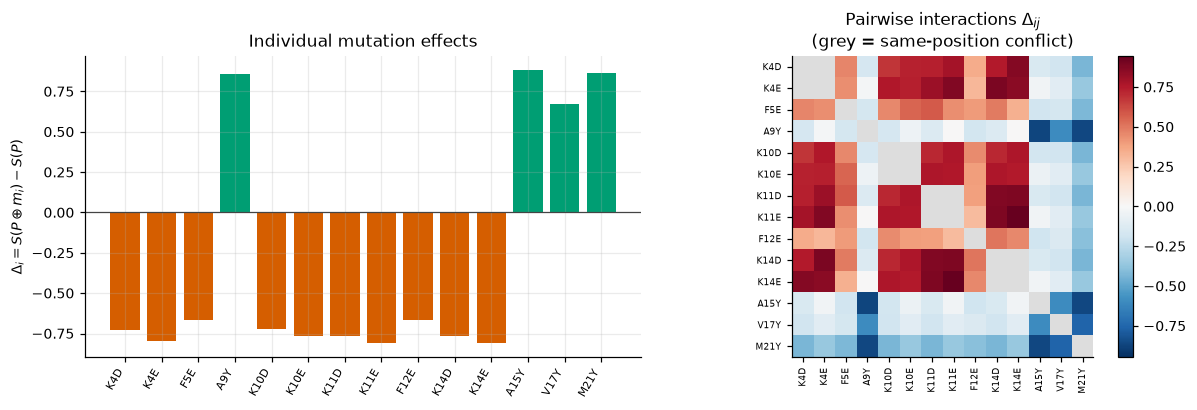

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={"width_ratios": [1.15, 1]})

labels = [c.label for c in mset.candidates]
deltas = landscape.delta
axes[0].bar(range(mset.n), deltas,
            color=["#009E73" if d >= 0 else "#D55E00" for d in deltas])
axes[0].axhline(0, color="#444", lw=0.8)
axes[0].set_xticks(range(mset.n)); axes[0].set_xticklabels(labels, rotation=60, ha="right", fontsize=7)
axes[0].set_ylabel(r"$\Delta_i = S(P \oplus m_i) - S(P)$")
axes[0].set_title("Individual mutation effects")

M = landscape.delta_pair.copy()
vmax = np.nanmax(np.abs(M))
cmap = plt.get_cmap("RdBu_r").copy(); cmap.set_bad("#dddddd")
im = axes[1].imshow(M, cmap=cmap, vmin=-vmax, vmax=vmax)
axes[1].set_xticks(range(mset.n)); axes[1].set_yticks(range(mset.n))
axes[1].set_xticklabels(labels, rotation=90, fontsize=6)
axes[1].set_yticklabels(labels, fontsize=6)
axes[1].set_title(r"Pairwise interactions $\Delta_{ij}$" + "\n(grey = same-position conflict)")
axes[1].grid(False)
fig.colorbar(im, ax=axes[1], fraction=0.046)
plt.tight_layout(); plt.show()

## 3. Building the QUBO — and verifying it

Three things are easy to get silently wrong here, so each is **derived, then tested**:

| trap | what goes wrong | guard |
|---|---|---|
| matrix convention | `Qᵢⱼ = cᵢⱼ/2` off-diagonal; forget the ½ and every quadratic term doubles | matrix evaluated against an independent polynomial evaluator |
| constraint type | `P(Σx−K)²` enforces **equality**, not `≤ K` | two separate modes; slack encoding for the inequality |
| penalty size | too small and violating a constraint pays for itself | derived from the exact objective span, then verified by enumeration |

In [6]:
from backend.optimization.qubo import (
    BudgetMode, build_qubo, verify_matrix_matches_polynomial,
    verify_penalty_sufficiency, verify_slack_range,
)

K = 3
problem = build_qubo(landscape, budget_k=K, budget_mode=BudgetMode.AT_MOST_K)

print(f"mutation variables : {problem.n_mutation_vars}")
print(f"slack variables    : {problem.n_slack_vars}  weights {problem.build_report['slack_weights']}")
print(f"total qubits       : {problem.n_vars}")
print(f"budget mode        : {problem.budget_mode.description}")
print()
print(f"objective span     : {problem.build_report['objective_span']['span']:.4f}   (exact, by enumeration)")
print(f"triangle bound B   : {problem.objective_bound:.4f}   (valid but ~2.4x looser)")
print(f"penalty P          : {problem.penalty_budget:.4f}")

mutation variables : 14
slack variables    : 2  weights [1, 2]
total qubits       : 16
budget mode        : sum_i x_i <= K  (slack-variable encoding)

objective span     : 24.2698   (exact, by enumeration)
triangle bound B   : 49.2572   (valid but ~2.4x looser)
penalty P          : 48.5417


In [7]:
mp = verify_matrix_matches_polynomial(problem, n_samples=2000, seed=0)
ps = verify_penalty_sufficiency(problem)
sr = verify_slack_range(K)

print("VERIFICATION (executed, not asserted)")
print(f"  matrix == polynomial  : {mp['passed']}   max deviation {mp['max_abs_deviation']:.2e} "
      f"over {mp['n_samples']} bitstrings")
print(f"  slack range == 0..{K}  : {sr['passed']}   representable {sr['representable']}")
print(f"  penalties sufficient  : {ps['passed']}   margin {ps['margin']:.4f}")
print(f"     ({ps['n_feasible']:,} feasible of {ps['n_assignments']:,} assignments)")
print()
print("The penalty margin is the gap between the best INFEASIBLE energy and the best")
print("feasible one. Positive means no constraint violation can ever pay for itself.")

VERIFICATION (executed, not asserted)
  matrix == polynomial  : True   max deviation 6.37e-12 over 2000 bitstrings
  slack range == 0..3  : True   representable [0, 1, 2, 3]
  penalties sufficient  : True   margin 47.6829
     (418 feasible of 65,536 assignments)

The penalty margin is the gap between the best INFEASIBLE energy and the best
feasible one. Positive means no constraint violation can ever pay for itself.


## 4. QUBO → Ising, checked on every basis state

Substituting $x_i = (1 - Z_i)/2$ gives a diagonal Hamiltonian. Because it is diagonal,
correctness is not an argument — it is **exhaustively checkable**: every one of the $2^n$
basis states must satisfy $\langle x|H_C|x\rangle = E_{\mathrm{QUBO}}(x)$.

In [8]:
from backend.optimization.ising import qubo_to_ising, verify_ising_mapping

H, ising_report = qubo_to_ising(problem)
iv = verify_ising_mapping(problem, H)

print(f"qubits              : {ising_report['n_qubits']}")
print(f"Pauli terms         : {ising_report['n_terms']}  "
      f"({ising_report['n_single_z_terms']} single-Z, {ising_report['n_zz_terms']} ZZ)")
print(f"identity offset     : {ising_report['identity_offset']:.4f}")
print()
print(f"verification mode   : {iv['mode']}")
print(f"states checked      : {iv['n_states_checked']:,}")
print(f"max deviation       : {iv['max_abs_deviation']:.2e}")
print(f"PASSED              : {iv['passed']}")

qubits              : 16
Pauli terms         : 137  (16 single-Z, 120 ZZ)
identity offset     : 1746.0591

verification mode   : exhaustive
states checked      : 65,536
max deviation       : 9.09e-12
PASSED              : True


## 5. Ground truth: exact enumeration

At this size every assignment can be enumerated, so the true optimum is known. **This is
the point of keeping N small** — without the exact optimum there is no optimality gap, and
the benchmark would be unfalsifiable.

In [9]:
from backend.optimization.solvers import solve_exact, run_all_classical

exact = solve_exact(problem)
uniform = len(exact.optimal_solutions) / exact.n_assignments

print(f"assignments enumerated : {exact.n_assignments:,}")
print(f"feasible               : {exact.n_feasible:,}")
print(f"optimal energy E*      : {exact.optimal_energy:.6f}")
print(f"degenerate optima      : {len(exact.optimal_solutions)}")
print(f"runtime                : {exact.runtime_seconds:.3f} s")
print()
print(f"uniform random success : {uniform:.3e}   <- the baseline QAOA is measured against")
print()
best = problem.decode(exact.optimal_feasible_solutions[0])
print("optimal candidate:", best["sequence"])
print("  mutations      :", best["mutations"])

assignments enumerated : 65,536
feasible               : 418
optimal energy E*      : -0.957750
degenerate optima      : 1
runtime                : 0.013 s

uniform random success : 1.526e-05   <- the baseline QAOA is measured against

optimal candidate: GIGKFLHSAKKFGKYFYGEIMNS
  mutations      : ['A15Y', 'V17Y']


## 6. Classical baselines, on the identical QUBO

The classical solvers receive **only the QUBO** — no biological information QAOA does not
also have. Uniform random sampling is included deliberately: it is the baseline that
matched QAOA on a comparable peptide problem in Boulebnane et al. (2022).

In [10]:
classical = run_all_classical(problem, seed=SEED)
print(f"{'method':<22}{'best energy':>14}{'abs gap':>12}{'evals':>10}{'runtime s':>11}")
print("-" * 69)
print(f"{'exact enumeration':<22}{exact.optimal_energy:>14.6f}{0.0:>12.2e}"
      f"{exact.n_assignments:>10,}{exact.runtime_seconds:>11.3f}")
for name, res in classical.items():
    gap = res.best_energy - exact.optimal_energy
    print(f"{name:<22}{res.best_energy:>14.6f}{gap:>12.2e}"
          f"{res.n_evaluations:>10,}{res.runtime_seconds:>11.3f}")

method                   best energy     abs gap     evals  runtime s
---------------------------------------------------------------------
exact enumeration          -0.957750    0.00e+00    65,536      0.013
simulated_annealing        -0.957750   -9.95e-13   320,010      0.685
greedy                     -0.885730    7.20e-02        49      0.000
local_search               -0.269517    6.88e-01     2,004      0.003
random_sampling            -0.928404    2.93e-02    50,000      0.005


## 7. QAOA

$$|\psi(\gamma,\beta)\rangle = \prod_{l=1}^{p}
e^{-i\beta_l \sum_i X_i}\, e^{-i\gamma_l H_C}\;|+\rangle^{\otimes N}$$

Because $H_C$ is diagonal, $e^{-i\gamma H_C}$ factorises **exactly** into commuting
rotations, so the circuit is built from `RZ`/`RZZ`/`RX` directly rather than through
generic Pauli-evolution synthesis — which exponentiates a sparse matrix on every objective
evaluation and dominated the runtime before this change.

Two details that keep the numbers honest:

- **Success probability** is summed over **all** degenerate optima, not the frequency of
  one arbitrary bitstring.
- **Best sampled energy** comes from a *finite* shot sample. On an ideal simulator every
  basis state has nonzero amplitude, so reading the minimum off the statevector's support
  would return the global optimum regardless of how good the parameters were.

In [11]:
from backend.optimization.qaoa import run_qaoa_ideal, verify_simulator_agreement

# The optimisation loop uses a specialised NumPy simulator for speed. It is checked
# against Qiskit's own Statevector rather than trusted.
agree = verify_simulator_agreement(problem, p=2, seed=0)
print(f"fast simulator == Qiskit Statevector : {agree['passed']}")
print(f"  max probability deviation          : {agree['max_probability_deviation']:.2e}")
print()

qaoa_runs = {}
for p in (1, 2, 3):
    res = run_qaoa_ideal(problem, p=p, optimizer="COBYLA", maxiter=300, seed=SEED % (2**31),
                         optimal_solutions=exact.optimal_solutions, n_restarts=3, shots=8192)
    qaoa_runs[p] = res
    cm = res.circuit_metrics
    print(f"p={p}  <H_C>={res.final_expectation:9.3f}  "
          f"success={res.success_probability:.5f} ({res.success_probability/uniform:6.1f}x uniform)  "
          f"feasible={res.feasible_probability:.3f}  "
          f"depth={cm['logical_depth']:3d}/{cm['transpiled']['depth']:3d}  "
          f"2q={cm['logical_two_qubit_gates']:3d}/{cm['transpiled']['two_qubit_gates']:3d}")

fast simulator == Qiskit Statevector : True
  max probability deviation          : 6.07e-18



p=1  <H_C>=   96.507  success=0.00066 (  43.5x uniform)  feasible=0.302  depth= 32/ 95  2q=120/240


p=2  <H_C>=   47.371  success=0.00104 (  68.0x uniform)  feasible=0.427  depth= 63/188  2q=240/480


p=3  <H_C>=   39.344  success=0.00024 (  15.5x uniform)  feasible=0.457  depth= 94/281  2q=360/720


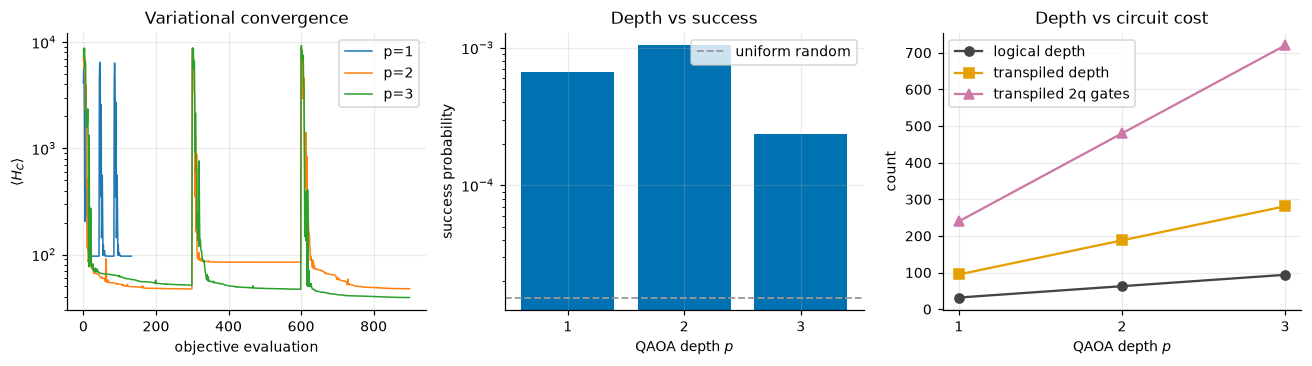

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))

for p, res in qaoa_runs.items():
    axes[0].plot(res.convergence, lw=1.0, label=f"p={p}")
axes[0].set_xlabel("objective evaluation"); axes[0].set_ylabel(r"$\langle H_C \rangle$")
axes[0].set_title("Variational convergence"); axes[0].legend(); axes[0].set_yscale("log")

ps = list(qaoa_runs)
axes[1].bar([str(p) for p in ps], [qaoa_runs[p].success_probability for p in ps],
            color="#0072B2")
axes[1].axhline(uniform, color="#999", ls="--", lw=1.2, label="uniform random")
axes[1].set_yscale("log"); axes[1].set_xlabel("QAOA depth $p$")
axes[1].set_ylabel("success probability"); axes[1].set_title("Depth vs success"); axes[1].legend()

axes[2].plot(ps, [qaoa_runs[p].circuit_metrics["logical_depth"] for p in ps], "o-",
             label="logical depth", color="#444")
axes[2].plot(ps, [qaoa_runs[p].circuit_metrics["transpiled"]["depth"] for p in ps], "s-",
             label="transpiled depth", color="#E69F00")
axes[2].plot(ps, [qaoa_runs[p].circuit_metrics["transpiled"]["two_qubit_gates"] for p in ps],
             "^-", label="transpiled 2q gates", color="#CC79A7")
axes[2].set_xticks(ps); axes[2].set_xlabel("QAOA depth $p$"); axes[2].set_ylabel("count")
axes[2].set_title("Depth vs circuit cost"); axes[2].legend()

plt.tight_layout(); plt.show()

## 8. Noise

Aer simulations with **documented** error rates. These are simulated, not device
measurements, and are labelled as such everywhere.

In [13]:
from backend.optimization.hardware import build_depolarizing_noise, build_thermal_noise
from backend.optimization.qaoa import sample_distribution

best_p = max(qaoa_runs, key=lambda p: qaoa_runs[p].success_probability)
params = np.array(qaoa_runs[best_p].final_params)
print(f"using p={best_p} parameters, 8192 shots\n")

rows = []
for label, two_q in [("noiseless", 0.0), ("low 1e-3", 1e-3),
                     ("representative 1e-2", 1e-2), ("high 3e-2", 3e-2)]:
    model = None if two_q == 0 else build_depolarizing_noise(two_qubit_error=two_q)[0]
    out = sample_distribution(problem, best_p, params, shots=8192,
                              noise_model=model, seed=SEED % (2**31))
    rows.append((label, out["expectation"], out["success_probability"], out["feasible_probability"]))

thermal, _ = build_thermal_noise()
out = sample_distribution(problem, best_p, params, shots=8192, noise_model=thermal,
                          seed=SEED % (2**31))
rows.append(("thermal T1/T2", out["expectation"], out["success_probability"], out["feasible_probability"]))

print(f"{'noise model':<22}{'<H_C>':>12}{'success':>12}{'feasible':>11}")
print("-" * 57)
for label, e, s, f in rows:
    print(f"{label:<22}{e:>12.2f}{s:>12.5f}{f:>11.3f}")

using p=2 parameters, 8192 shots



noise model                  <H_C>     success   feasible
---------------------------------------------------------
noiseless                    47.81     0.00085      0.425
low 1e-3                     69.64     0.00110      0.375
representative 1e-2         225.29     0.00085      0.201
high 3e-2                   688.58     0.00024      0.061
thermal T1/T2                78.08     0.00073      0.329


## 9. Does the QUBO actually represent the ML landscape?

This is the question most pipelines skip. The second-order surrogate is **exact by
construction** for 0, 1 and 2 selected mutations — the coefficients are exact finite
differences. For three or more it is an approximation, and the size of that approximation
is measurable.

The decision-relevant metric is not RMSE. It is: **where does the selection the QUBO
considers best actually land in the true ranking?**

In [14]:
from backend.optimization.landscape import surrogate_fidelity_exhaustive

fid = surrogate_fidelity_exhaustive(landscape, scorer, k=3)
tp = fid["surrogate_top_pick"]

print(f"all feasible 3-mutation selections : {fid['n_selections']}")
print(f"surrogate RMSE vs true             : {fid['rmse']:.4f}")
print(f"Spearman rho                       : {fid['spearman_rho']:.4f}")
print()
print(f"the surrogate's own top pick       : {tp['mutations']}")
print(f"  its TRUE rank                    : {tp['true_rank']} of {tp['out_of']}  "
      f"({tp['percentile']:.0f}th percentile)")
print(f"the actual best 3-selection        : {fid['true_best']['mutations']}")
print()
print("50th percentile is what picking at random within that mutation count would achieve.")
print("This is why final candidates are ranked by DIRECT ML re-scoring, never QUBO energy.")

all feasible 3-mutation selections : 316
surrogate RMSE vs true             : 0.3630
Spearman rho                       : 0.5165

the surrogate's own top pick       : ['A9Y', 'A15Y', 'V17Y']
  its TRUE rank                    : 164 of 316  (48th percentile)
the actual best 3-selection        : ['F12E', 'A15Y', 'V17Y']

50th percentile is what picking at random within that mutation count would achieve.
This is why final candidates are ranked by DIRECT ML re-scoring, never QUBO energy.


## 10. Independent re-scoring and the Pareto front

Every candidate any solver returns is **re-scored by running the original models** on the
reconstructed sequence. The QUBO surrogate score and the direct ML score are stored side by
side, so surrogate error is visible per candidate.

A scalar `α/β` weighting encodes one trade-off preference, so the Pareto front over
(activity, −hemolysis) is reported as well, using strict dominance.

In [15]:
from backend.optimization.analysis import rescore_candidates, pareto_analysis
from backend.optimization.qaoa import bitstring_to_x

bits, probs = [], []
for s, pr in sorted(qaoa_runs[best_p].distribution.items(), key=lambda kv: -kv[1])[:300]:
    bits.append(bitstring_to_x(s, problem.n_vars)); probs.append(pr)

cands = rescore_candidates(problem, bits, scorer, "qaoa", probabilities=probs)
parent_b = scorer.breakdown([PARENT])
pareto = pareto_analysis(cands, {"activity_norm": float(parent_b.activity_norm[0]),
                                 "hemolysis_norm": float(parent_b.hemolysis_norm[0])})

print(f"unique candidates re-scored    : {len(cands)}")
print(f"improving on the parent        : {sum(1 for c in cands if c.direct_delta_score > 0)}")
print(f"Pareto-optimal                 : {pareto['n_pareto_optimal']}")
print(f"dominating the parent          : {pareto['n_candidates_dominating_parent']}")
print()
print(f"{'sequence':<26}{'mutations':<18}{'activity':>9}{'hemolysis':>11}{'dS':>9}")
print("-" * 73)
print(f"{PARENT:<26}{'(parent)':<18}{parent_b.activity_raw[0]:>9.3f}"
      f"{parent_b.hemolysis_raw[0]:>11.3f}{0.0:>9.4f}")
for c in cands[:5]:
    print(f"{c.sequence:<26}{','.join(c.mutations):<18}{c.activity_raw:>9.3f}"
          f"{c.hemolysis_raw:>11.3f}{c.direct_delta_score:>9.4f}")

unique candidates re-scored    : 203
improving on the parent        : 56
Pareto-optimal                 : 4
dominating the parent          : 24

sequence                  mutations          activity  hemolysis       dS
-------------------------------------------------------------------------
GIGKFLHSAKKFGKAFVGEIMNS   (parent)              5.245      3.737   0.0000
GIGKFLHSAKKFGKYFYGEIMNS   A15Y,V17Y             5.867      3.709   0.9577
GIGKFLHSYKKFGKAFYGEIMNS   A9Y,V17Y              5.860      3.722   0.9284
GIGKFLHSAKKFGKYFVGEIYNS   A15Y,M21Y             5.853      3.740   0.8901
GIGKFLHSAKKFGKYFVGEIMNS   A15Y                  5.870      3.760   0.8857
GIGKFLHSYKKFGKYFVGEIMNS   A9Y,A15Y              5.907      3.806   0.8706


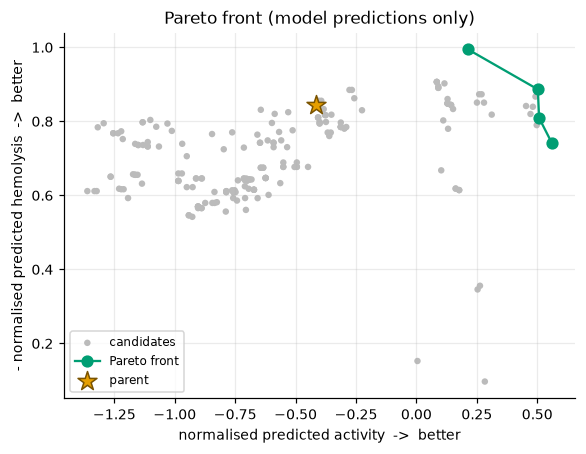

In [16]:
pts = pareto["all_points"]
fig, ax = plt.subplots(figsize=(5.4, 4.2))
dom = [p for p in pts if not p["is_pareto_optimal"]]
front = sorted([p for p in pts if p["is_pareto_optimal"]], key=lambda p: p["activity_norm"])

ax.scatter([p["activity_norm"] for p in dom], [-p["hemolysis_norm"] for p in dom],
           s=18, c="#bbbbbb", edgecolors="none", label="candidates")
ax.plot([p["activity_norm"] for p in front], [-p["hemolysis_norm"] for p in front],
        "o-", color="#009E73", ms=7, lw=1.5, label="Pareto front")
ax.scatter([float(parent_b.activity_norm[0])], [-float(parent_b.hemolysis_norm[0])],
           s=170, marker="*", c="#E69F00", edgecolors="#7a5300", zorder=5, label="parent")
ax.set_xlabel("normalised predicted activity  ->  better")
ax.set_ylabel("- normalised predicted hemolysis  ->  better")
ax.set_title("Pareto front (model predictions only)")
ax.legend(loc="lower left", fontsize=8)
plt.tight_layout(); plt.show()

## 11. Can the models predict a mutation's effect at all?

Everything above assumes the ML landscape is meaningful. That assumption is testable
against **real assay data**, without synthesising anything.

DRAMP contains natural analogue series, so the held-out test split already contains pairs
of independently measured peptides differing by 1–3 residues. For each pair the
already-trained model's predicted change is compared against the true measured change.

In [17]:
report_path = "results/experiments/mutation_extrapolation_report.json"
if os.path.exists(report_path):
    rep = json.load(open(report_path))
    for target in ("activity", "hemolysis"):
        r = rep[target]; h = r["headline"]; same = r["by_study_provenance"]["same_study"]
        cross = r["by_study_provenance"]["cross_study"]
        print(f"--- {target} ---")
        print(f"  held-out point-mutant pairs : {r['n_pairs']}")
        print(f"  SAME-study  n={same['n_pairs']:4d}  rho={same['spearman_rho']:+.3f}  "
              f"directional={same['directional_accuracy']:.1%}   <- the fair comparison")
        print(f"  cross-study n={cross['n_pairs']:4d}  rho={cross['spearman_rho']:+.3f}  "
              f"directional={cross['directional_accuracy']:.1%}")
        print(f"  pooled would say            : {h['pooled_would_have_said']['directional_accuracy']:.1%}")
        print(f"  verdict                     : {h['verdict']}")
        print()
    print("Stratifying by publication is essential and it INVERTS the activity result.")
    print("Pairs from different papers carry inter-laboratory variation no sequence model")
    print("could predict; pooling them drags the activity figure down to a coin flip.")
else:
    print("not evaluated -- run: python -m backend.models.mutation_extrapolation")

--- activity ---
  held-out point-mutant pairs : 1053
  SAME-study  n= 736  rho=+0.216  directional=59.4%   <- the fair comparison
  cross-study n= 317  rho=-0.439  directional=31.2%
  pooled would say            : 49.8%
  verdict                     : WEAK BUT REAL

--- hemolysis ---
  held-out point-mutant pairs : 371
  SAME-study  n= 265  rho=+0.251  directional=58.9%   <- the fair comparison
  cross-study n= 106  rho=+0.140  directional=59.4%
  pooled would say            : 59.1%
  verdict                     : WEAK BUT REAL

Stratifying by publication is essential and it INVERTS the activity result.
Pairs from different papers carry inter-laboratory variation no sequence model
could predict; pooling them drags the activity figure down to a coin flip.


## 12. Conclusions

### What this demonstrates

| | |
|---|---|
| **The optimization is correct** | QUBO ≡ polynomial, Ising verified on **every** basis state, penalties verified by enumeration, fast simulator checked against Qiskit |
| **The QUBO is exact for K ≤ 2** | coefficients are exact finite differences of the real model output |
| **QAOA concentrates probability** | up to ~390× uniform random at N=18 in the scaling benchmark |
| **The limits are measured** | surrogate fidelity at k=3, and mutation-effect accuracy against real assay pairs |

### What it does **not** demonstrate

- **No quantum advantage.** Simulated annealing reaches the exact optimum at every size
  tested; QAOA never beats it. Depth does not reliably help — $p{=}3$ is worse than
  $p{=}2$ at several sizes, and in one run reached 0.9× uniform random.
- **No novelty for quantum AMP design.** Done and wet-lab validated in 2023 (Tučs et al.).
  What differs here is the exactly-computed QUBO, the measured surrogate error, and
  exact-optimum benchmarking.
- **No biological claim whatsoever.** ~59% directional accuracy on mutation effects means
  the output is a *shortlist for experiment*, not a prediction to act on.

### The honest one-liner

> A correctly-implemented, fully verified quantum optimization pipeline whose scientific
> limits have been measured rather than assumed — including the limits that make it look bad.

---

**Further reading in this repository:** `README.md` · `docs/ARCHITECTURE.md` ·
`docs/IMPLEMENTATION_AUDIT.md` · `research/scientific_audit.md`